Plot graphs of C vs. t and ln(C) vs. t for the following:
- IV administration with $V_d = 70 L$ and a $k_e$ of $0.175 hr^{-1}$
- For the IV administration curve (only) plot your results using the analytical solution to the differnetial equation, the results using Euler's method and the results using an ODE solver in either MatLab or Python. How do the results for Euler's method change as you change the time-interval step size?
- Compare your results for IV administration with graphs of C and ln(C) vs. t Oral administration with the $V_d$ and $k_e$ and with values for $k_a$ of $0.35 hr^{-1}$ and $0.5 hr^{-1}$. Do the calculations for oral administration for each value of $k_a$ with values for $F$ of 1.0, 0.7, 0.4, and 0.1.
- Explain what these results tell your about the parameters and how they affect the temporal behavior.
- Where do the IV and oral curves for C vs. t cross? What is the significance of this?

### C vs. t and ln(C) vs. t for IV Administration Using Analytical Soluition, Euler's Method, and ODE Solver

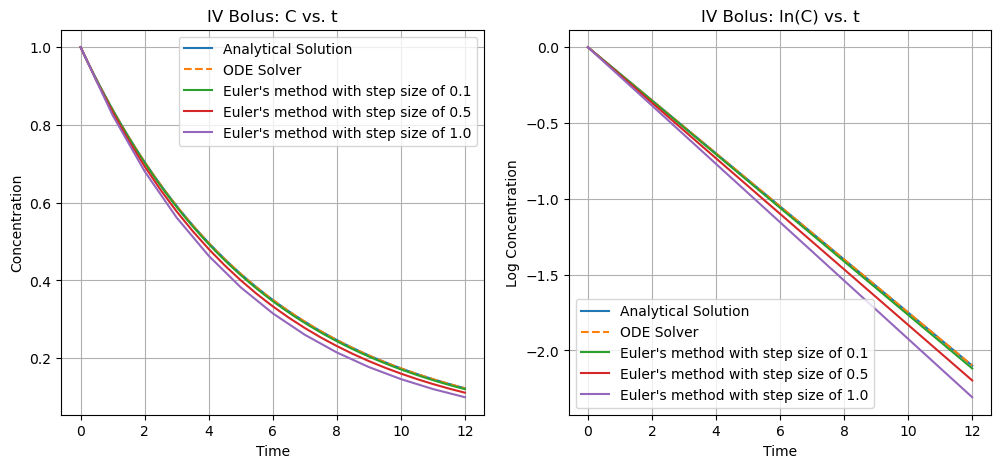

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set parameters
Cp0 = 1                                  # Initial drug concentration in the plasma in mg/L (check unit)
t0 = 0.0                                 # Initial time in hr
tf = 12.0                                # Final time in hr
h = [0.1, 0.5, 1.0]                      # Step size
num_steps = [int(tf/step) for step in h] # Number of steps
Vd = 70                                  # Volume distribution of the drug in the body in L
ke = 0.175                               # Rate constant for elimination in hr^-1

# Define time span to evaluate the concentration
t_span = (t0, tf)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Analytical solution
IV_analytic = Cp0 * np.exp(-ke * t_eval)

# Define the system of DFQ
def IV_admin(t, Concentration):
    Cp = Concentration
    dCpdt = -ke * Cp
    return [dCpdt]

# Euler's method implementation
def euler_method(Cp0, t0, h, num_steps):
    Cps = [Cp0]
    ts = [t0]
    for _ in range(num_steps):
        dCpdt = IV_admin(t0, Cp0)[0]
        Cp0 = Cp0 + h * dCpdt
        t0 = t0 + h
        Cps.append(Cp0)
        ts.append(t0)
    return np.array(ts), np.array(Cps)

# Initial concentrations
initial_concentrations = [Cp0] # Cp0 is not given in the problem

# Solve the system
solution_IV = solve_ivp(IV_admin, t_span, initial_concentrations, t_eval = t_eval)

# Plot results
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Left plot: C vs t
axes[0].plot(t_eval, IV_analytic, label = 'Analytical Solution')
axes[0].plot(solution_IV.t, solution_IV.y[0], '--', label = 'ODE Solver')
for i in range(len(h)):
    t, Cp = euler_method(Cp0, t0, h[i], num_steps[i])
    axes[0].plot(t, Cp, label = f"Euler's method with step size of {h[i]}")
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Concentration')
axes[0].set_title('IV Bolus: C vs. t')
axes[0].legend()
axes[0].grid(True)

# Right plot: ln(C) vs t
axes[1].plot(t_eval, np.log(IV_analytic), label = 'Analytical Solution')
axes[1].plot(solution_IV.t, np.log(solution_IV.y[0]), '--', label = 'ODE Solver')
for i in range(len(h)):
    t, Cp = euler_method(Cp0, t0, h[i], num_steps[i])
    axes[1].plot(t, np.log(Cp), label = f"Euler's method with step size of {h[i]}")
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Log Concentration')
axes[1].set_title('IV Bolus: ln(C) vs. t')
axes[1].legend()
axes[1].grid(True)
plt.show()

Using the Euler's method, as the step size decreases, the plot gets closer to the analytical solution. As the number of iteration increases with decreasing step size, the apprixmation gets closer to the real value.

### C vs. t and ln(C) vs. t for IV and Oral Administration with Varying Constants
#### Case 1. Varying F

/var/folders/vy/1tk78kxx43q4t7wfbcs37mn00000gn/T/ipykernel_46835/1587688211.py:48: RuntimeWarning: divide by zero encountered in log
  axes[1].plot(solution_Oral.t, np.log(solution_Oral.y[1]), label = f'Oral Administration with F = {F[i]}')


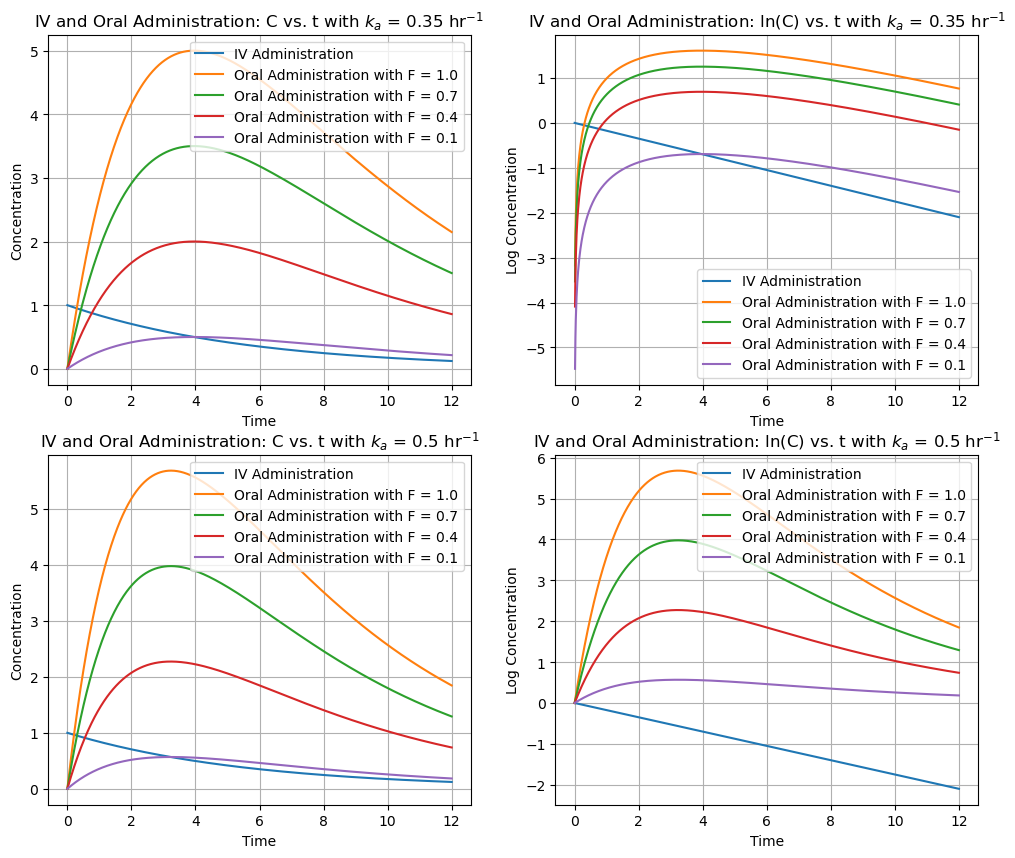

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set parameters
CA0 = 10                   # Initial administered drug concentration in mg/L (check unit) 
Cp0 = 0                    # Initial drug concentration in the plasma in mg/L (check unit)
t0 = 0.0                   # Initial time in hr
tf = 12.0                  # Final time in hr
Vd = 70                    # Volume distribution of the drug in the body in L
ke = 0.175                 # Rate constant for elimination in hr^-1
ka = [0.35, 0.5]           # Rate constant for adsorption in hr^-1
F = [1.0, 0.7, 0.4, 0.1]   # Bioavailaility

# Define the system of DFQ
def Oral_admin(t, Concentrations, F, ka):
    CA, Cp = Concentrations
    dCAdt = -ka * CA
    dCpdt = F * ka * CA - ke * Cp
    return [dCAdt, dCpdt]

# Time to plug into rate laws
t_span = (t0, tf)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Initial concentrations
initial_concentrations = [CA0, Cp0] # Cp0 is not given in the problem

# Plot results varying F
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten()

# Top-left plot: C vs t with ka = 0.35
axes[0].plot(solution_IV.t, solution_IV.y[0], label = 'IV Administration')
for i in range(len(F)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[i], ka[0]),t_eval = t_eval)
    axes[0].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with F = {F[i]}')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Concentration')
axes[0].set_title(f'IV and Oral Administration: C vs. t with $k_a$ = 0.35 hr$^{{-1}}$')
axes[0].legend()
axes[0].grid(True)

# Top-right plot: ln(C) vs t with ka = 0.35
axes[1].plot(solution_IV.t, np.log(solution_IV.y[0]), label = 'IV Administration')
for i in range(len(F)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[i], ka[0]),t_eval = t_eval)
    axes[1].plot(solution_Oral.t, np.log(solution_Oral.y[1]), label = f'Oral Administration with F = {F[i]}')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Log Concentration')
axes[1].set_title(f'IV and Oral Administration: ln(C) vs. t with $k_a$ = 0.35 hr$^{{-1}}$')
axes[1].legend()
axes[1].grid(True)

# Bottom-left plot: C vs t with ka = 0.5
axes[2].plot(solution_IV.t, solution_IV.y[0], label = 'IV Administration')
for i in range(len(F)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[i], ka[1]),t_eval = t_eval)
    axes[2].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with F = {F[i]}')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Concentration')
axes[2].set_title(f'IV and Oral Administration: C vs. t with $k_a$ = 0.5 hr$^{{-1}}$')
axes[2].legend()
axes[2].grid(True)

# Bottom-right plot ln(C) vs. t with ka = 0.5
axes[3].plot(solution_IV.t, np.log(solution_IV.y[0]), label = 'IV Administration')
for i in range(len(F)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[i], ka[1]),t_eval = t_eval)
    axes[3].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with F = {F[i]}')
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Log Concentration')
axes[3].set_title(f'IV and Oral Administration: ln(C) vs. t with $k_a$ = 0.5 hr$^{{-1}}$')
axes[3].legend()
axes[3].grid(True)
plt.show()

#### Case 2. Varying $k_a$

/var/folders/vy/1tk78kxx43q4t7wfbcs37mn00000gn/T/ipykernel_37052/306849596.py:20: RuntimeWarning: divide by zero encountered in log
  axes[1].plot(solution_Oral.t, np.log(solution_Oral.y[1]), label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')


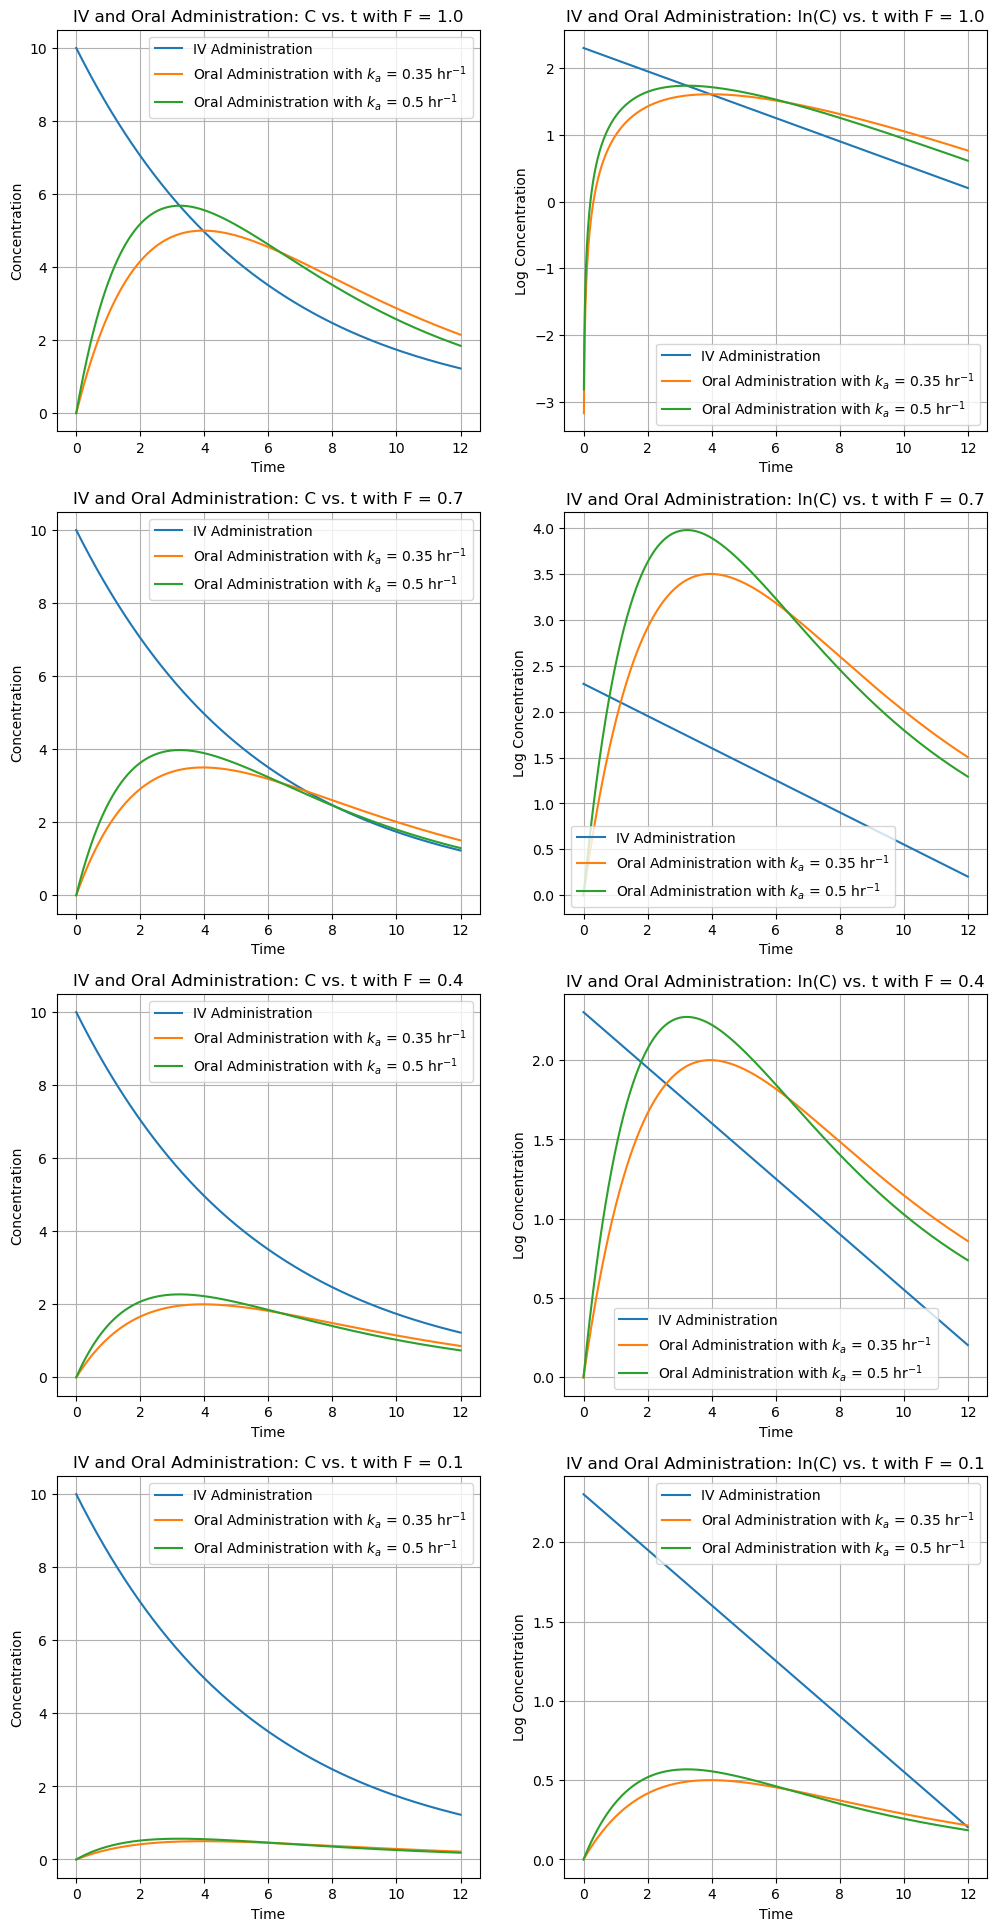

In [3]:
# Plot results varying ka
fig, axes = plt.subplots(4, 2, figsize = (12, 24))
axes = axes.flatten()

# Top-left plot: C vs t with F = 1.0
axes[0].plot(solution_IV.t, solution_IV.y[0], label = 'IV Administration')
for i in range(len(ka)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[0], ka[i]),t_eval = t_eval)
    axes[0].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Concentration')
axes[0].set_title(f'IV and Oral Administration: C vs. t with F = 1.0')
axes[0].legend()
axes[0].grid(True)

# Top-right plot: ln(C) vs t with F = 1.0
axes[1].plot(solution_IV.t, np.log(solution_IV.y[0]), label = 'IV Administration')
for i in range(len(ka)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[0], ka[i]),t_eval = t_eval)
    axes[1].plot(solution_Oral.t, np.log(solution_Oral.y[1]), label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Log Concentration')
axes[1].set_title(f'IV and Oral Administration: ln(C) vs. t with F = 1.0')
axes[1].legend()
axes[1].grid(True)

# Second row-left plot: C vs t with F = 0.7
axes[2].plot(solution_IV.t, solution_IV.y[0], label = 'IV Administration')
for i in range(len(ka)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[1], ka[i]),t_eval = t_eval)
    axes[2].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Concentration')
axes[2].set_title(f'IV and Oral Administration: C vs. t with F = 0.7')
axes[2].legend()
axes[2].grid(True)

# Second row-right plot ln(C) vs. t with F = 0.7
axes[3].plot(solution_IV.t, np.log(solution_IV.y[0]), label = 'IV Administration')
for i in range(len(ka)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[1], ka[i]),t_eval = t_eval)
    axes[3].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Log Concentration')
axes[3].set_title(f'IV and Oral Administration: ln(C) vs. t with F = 0.7')
axes[3].legend()
axes[3].grid(True)

# Third row-left plot: C vs t with F = 0.4
axes[4].plot(solution_IV.t, solution_IV.y[0], label = 'IV Administration')
for i in range(len(ka)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[2], ka[i]),t_eval = t_eval)
    axes[4].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')
axes[4].set_xlabel('Time')
axes[4].set_ylabel('Concentration')
axes[4].set_title(f'IV and Oral Administration: C vs. t with F = 0.4')
axes[4].legend()
axes[4].grid(True)

# Third row-right plot ln(C) vs. t with F = 0.4
axes[5].plot(solution_IV.t, np.log(solution_IV.y[0]), label = 'IV Administration')
for i in range(len(ka)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[2], ka[i]),t_eval = t_eval)
    axes[5].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')
axes[5].set_xlabel('Time')
axes[5].set_ylabel('Log Concentration')
axes[5].set_title(f'IV and Oral Administration: ln(C) vs. t with F = 0.4')
axes[5].legend()
axes[5].grid(True)

# Bottom-left plot: C vs t with F = 0.1
axes[6].plot(solution_IV.t, solution_IV.y[0], label = 'IV Administration')
for i in range(len(ka)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[3], ka[i]),t_eval = t_eval)
    axes[6].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')
axes[6].set_xlabel('Time')
axes[6].set_ylabel('Concentration')
axes[6].set_title(f'IV and Oral Administration: C vs. t with F = 0.1')
axes[6].legend()
axes[6].grid(True)

# Bottom-right plot ln(C) vs. t with F = 0.1
axes[7].plot(solution_IV.t, np.log(solution_IV.y[0]), label = 'IV Administration')
for i in range(len(ka)):
    solution_Oral = solve_ivp(Oral_admin, t_span, initial_concentrations, args = (F[3], ka[i]),t_eval = t_eval)
    axes[7].plot(solution_Oral.t, solution_Oral.y[1], label = f'Oral Administration with $k_a$ = {ka[i]} hr$^{{-1}}$')
axes[7].set_xlabel('Time')
axes[7].set_ylabel('Log Concentration')
axes[7].set_title(f'IV and Oral Administration: ln(C) vs. t with F = 0.1')
axes[7].legend()
axes[7].grid(True)
plt.show()

Overall, we can see that as the values of $F$ and $k_a$ gets larger, meaning higher bioavailability and absorption, the C vs. t plot yield greater AUC (area under the curve). In the context of temporal behavior, the drug remains in the body not only for longer period of time but also at higher concentrations.

Where do the IV and oral curves for C vs. t cross? What is the significance of this?